# 第10章 畳み込みネットワーク (Convolutional Networks)
## 10.4 物体検出 (Object Detection)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第10章「畳み込みネットワーク」第10.4節「物体検出 (Object Detection)」の全6小節（10.4.1 〜 10.4.6）の完全な理論解説、数学的定式化、教科書図版（Figure 10.19 〜 10.25 全7枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **10.4.1 バウンディングボックス (Bounding Boxes)**
   - 物体位置の連続座標表現：中心・サイズ型 $(b_x, b_y, b_W, b_H)$ と左上・右下型 $(x_1, y_1, x_2, y_2)$
   - 分類と回帰のマルチタスク学習（Multi-Task Loss）
   - クラス確率の2つの定式化（演習 10.11）：$(C+1)$ クラス単一ソフトマックス vs 物体存在確率＋クラス条件付き確率
   - 図 10.19: 複数クラス（車、歩行者、信号機）のバウンディングボックスによるアノテーション
3. **10.4.2 領域重なり度 IoU (Intersection-over-Union)**
   - 幾何学的定義：$\mathrm{IoU} = \frac{\mathrm{Area}(B \cap G)}{\mathrm{Area}(B \cup G)}$
   - スケール不変性と評価閾値（$\mathrm{IoU} \ge 0.5$ の適合判定基準）
   - なぜ IoU は損失関数ではなく主に評価指標として用いられるのか
   - 図 10.20: 積集合領域（Area of Intersection）と和集合領域（Area of Union）の可視化
4. **10.4.3 スライディングウィンドウと畳み込み高速化 (Sliding Windows)**
   - 切り出し分類器の走査と計算重複（Redundancy）の発生（図 10.21）
   - 全結合層の畳み込み層への読み替え（Fully Convolutional Transformation）
   - 図 10.22: $6 \times 6$ 画像に対する基本 CNN アーキテクチャ
   - 図 10.23: $8 \times 8$ 画像への拡張と畳み込み的重み共有による劇的計算削減
   - 演習 10.12 の厳密計算：素朴な9回走査（1,332 乗算）vs 畳み込み走査（340 乗算）の約 $3.92$ 倍高速化
5. **10.4.4 スケール横断検出 (Detection Across Scales)**
   - 異なるスケールとアスペクト比（座った猫 vs 寝そべった猫）への対応
   - 固定受容野ウィンドウと画像ピラミッド（Image Pyramid）／座標逆変換
   - 図 10.24: 水平スケーリングと原画像空間へのバウンディングボックス逆投影
6. **10.4.5 重複抑制 NMS (Non-Max Suppression)**
   - 同一物体に対する重複検出バウンディングボックスの排除アルゴリズム
   - 確信度閾値フィルタリング $\to$ 最高スコア抽出 $\to$ IoU 閾値（$0.5$）による重複間引きループ
   - 図 10.25: NMS による勝者矩形（0.95, 0.91）の選定と重複候補（0.81, 0.75）の抑制
7. **10.4.6 高速領域提案ネットワーク (Fast Region CNNs)**
   - 古典的領域提案（Selective Search）から深層モデルへの進化
   - R-CNN $\to$ Fast R-CNN（RoI Pooling による特徴マップ共有）$\to$ Faster R-CNN（RPN: Region Proposal Network）
   - グリッドセル基準の直接回帰（YOLO, SSD, OverFeat）
8. **数値検証セル**
9. **まとめと次節 10.5（画像セグメンテーション）への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートの設定
repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
setup_style()


## 2. 10.4.1 バウンディングボックス (Bounding Boxes)

画像分類（Classification）が「画像全体に対して単一のクラスラベル」を割り当てるのに対し、**物体検出（Object Detection）**は画像内に存在する複数の物体の**カテゴリ分類（What）**と**空間的位置特定（Where）**を同時に行います。

### 幾何学的パラメータ表現
物体を囲む最小外接矩形は**バウンディングボックス（Bounding Box）**と呼ばれ、一般に以下の4次元連続ベクトルで定義されます：
$$\mathbf{b} = (b_x, b_y, b_W, b_H)$$
- $(b_x, b_y)$: 矩形の幾何学的中心座標
- $b_W, b_H$: 矩形の幅（Width）および高さ（Height）

正規化座標系（左上を $(0, 0)$、右下を $(1, 1)$ とする）を用いることで、入力解像度に依存しないスケール普遍な表現が可能となります。

### 分類と位置特定のマルチタスク損失関数 (Multi-Task Loss)
CNNは通常、離散クラス確率を出力するソフトマックスヘッドと、連続座標を出力する線形回帰ヘッドを同時に備えます：
$$\mathcal{L} = \mathcal{L}_{\text{cls}}(\mathbf{p}, \mathbf{t}) + \lambda [t \neq 0] \mathcal{L}_{\text{reg}}(\mathbf{b}, \mathbf{b}^*)$$
ここで $[t \neq 0]$ は背景クラス以外の真の物体が存在する場合にのみ回帰損失を計算する指示関数であり、$\lambda$ は損失間のバランスを司るハイパーパラメータです。

---

### クラス確率の定式化（演習 10.11 の考察）
$C$ 個の物体クラスを検出する際、以下の2通りの確率モデリングが可能です：
1. **$(C + 1)$ クラス単一ソフトマックス**:
   - 背景（Background: 物体が存在しない）をクラス $0$ とし、全 $(C+1)$ クラスの確率ベクトルを出力：
     $$\sum_{c=0}^C p_c = 1$$
2. **2段階確率モデル（物体存在確率 $\times$ 条件付きクラス確率）**:
   - 物体が存在する確率を $P(\text{object}) = 1 - p_0$ とし、物体が存在するという条件のもとでの各クラス確率を $P(c \mid \text{object})$ とします。
   - 両者の数学的関係は以下のように直結します：
     $$P(c \mid \text{object}) = \frac{p_c}{1 - p_0} = \frac{p_c}{\sum_{c'=1}^C p_{c'}} \quad (c \in \{1, \dots, C\})$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_19.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_19.png


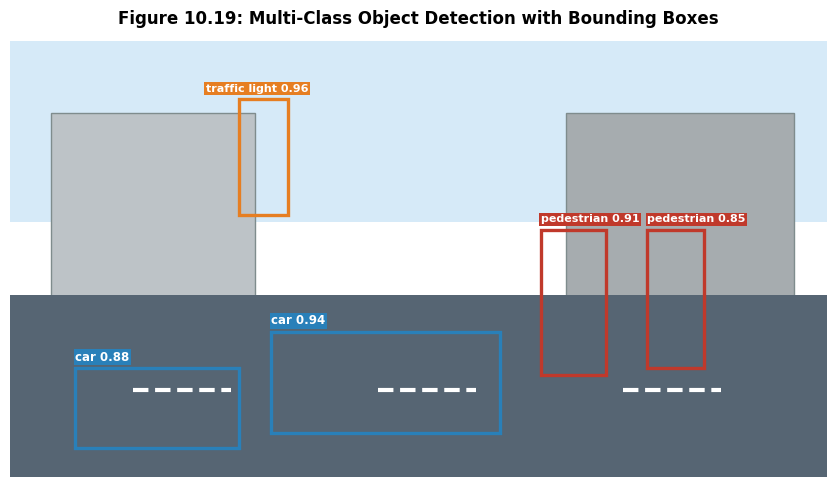

In [2]:
# Figure 10.19: 複数クラスのバウンディングボックスによる物体検出
from common.object_detection import generate_figure_10_19
import matplotlib.pyplot as plt

fig10_19 = generate_figure_10_19()
plt.show()


### Figure 10.19 の分析
道路シーンにおいて、異なるアスペクト比とスケールを持つ複数クラスのインスタンス（青: 車、赤: 歩行者、橙: 信号機）が各々の物体境界に密着したバウンディングボックスによって正確に切り分けられています。


## 3. 10.4.2 領域重なり度 IoU (Intersection-over-Union)

予測されたバウンディングボックス $B$ と正解アノテーション（Ground Truth） $G$ の空間的一致度を定量化する標準的な指標が **IoU (Intersection-over-Union: Jaccard指数)** です。

### 数学的定義
$$\mathrm{IoU}(B, G) = \frac{\mathrm{Area}(B \cap G)}{\mathrm{Area}(B \cup G)} = \frac{\mathrm{Area}(B \cap G)}{\mathrm{Area}(B) + \mathrm{Area}(G) - \mathrm{Area}(B \cap G)}$$

### 性質と利点
1. **有界性**: 常に $0 \le \mathrm{IoU} \le 1$ であり、完全一致のとき $\mathrm{IoU} = 1$、共通部分を持たないとき $\mathrm{IoU} = 0$ となります。
2. **スケール不変性**: 画像中の物体の絶対的なピクセルサイズ（近景の巨大な車 vs 遠景の極小な車）に依存せず、重なり度合いを公平に評価できます。
3. **過大・過小予測のペナルティ**: $B$ が $G$ を完全に包含して過大である場合、積集合 $\mathrm{Area}(B \cap G) = \mathrm{Area}(G)$ ですが、和集合 $\mathrm{Area}(B \cup G) = \mathrm{Area}(B)$ が肥大化するため、IoU は低下します。

一般に、ベンチマーク評価（PASCAL VOC や COCO）では $\mathrm{IoU} \ge 0.5$（または $0.75$）を満たす検出が「正解（True Positive）」と判定されます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_20.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_20.png


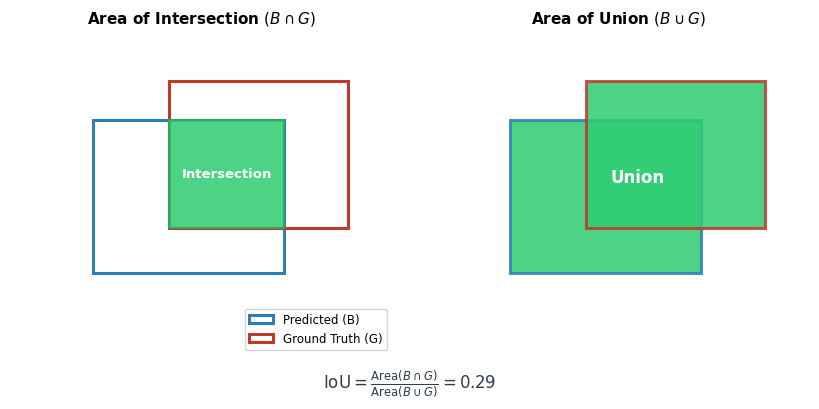

In [3]:
# Figure 10.20: IoU (積集合領域 vs 和集合領域) の可視化
from common.object_detection import generate_figure_10_20
import matplotlib.pyplot as plt

fig10_20 = generate_figure_10_20()
plt.show()


## 4. 10.4.3 スライディングウィンドウと畳み込み高速化 (Sliding Windows)

物体検出の古典的アプローチは、あらかじめ訓練された固定入力サイズの画像分類器を、画像全体にわたってストライド走査させる**スライディングウィンドウ（Sliding Window）**法です。

### 計算冗長性の発生 (Figure 10.21)
隣接する2つのウィンドウ位置（赤と青）を独立にCNNに入力すると、中央の広大な重なり領域（緑色の受容野）に属するピクセルの特徴抽出が完全に重複して再計算されてしまいます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_21.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_21.png


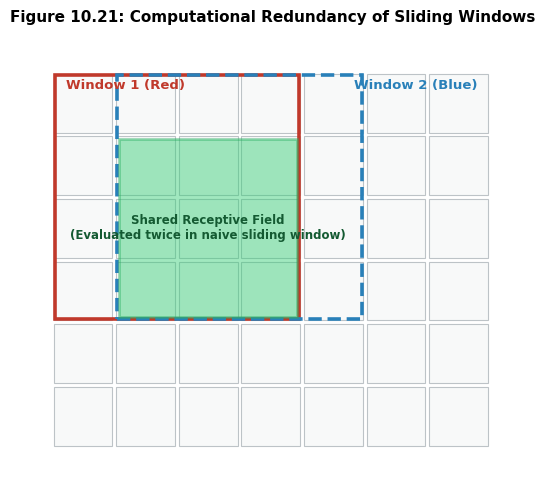

In [4]:
# Figure 10.21: スライディングウィンドウの計算冗長性
from common.object_detection import generate_figure_10_21
import matplotlib.pyplot as plt

fig10_21 = generate_figure_10_21()
plt.show()


### 全結合層の畳み込み層への転換 (Figure 10.22 & Figure 10.23)
Sermanet et al. (2013) は、ネットワークの最終段の全結合（FC）層を「カーネルサイズが入力特徴マップの空間サイズと同一の畳み込み層」とみなすことで、入力画像サイズをそのまま拡大して**1回のフォワードパスで全ウィンドウ位置の予測を並列計算できる**ことを示しました。

- **基本モデル（図 10.22）**:
  - 入力: $6 \times 6$ 画像
  - 畳み込み層: $3 \times 3$ フィルタ（Valid, Stride 1） $\to 4 \times 4$ 特徴マップ
  - プーリング層: $2 \times 2$ Max-Pool（Stride 2） $\to 2 \times 2$ マップ
  - FC層: $2 \times 2$ 結合 $\to 1$ 出力ユニット


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_22.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_22.png


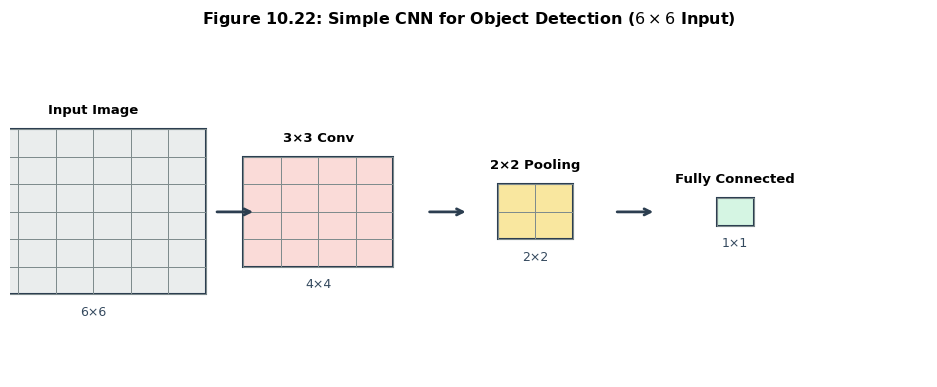

In [5]:
# Figure 10.22: 基本 CNN アーキテクチャ (6x6 入力)
from common.object_detection import generate_figure_10_22
import matplotlib.pyplot as plt

fig10_22 = generate_figure_10_22()
plt.show()


### 拡張入力への適用と計算効率の厳密導出 (演習 10.12)
このネットワークをそのまま $8 \times 8$ の大きな入力画像に適用します（図 10.23）：
- 入力: $8 \times 8$
- 畳み込み層: $3 \times 3$ フィルタ $\to (8 - 3 + 1) \times (8 - 3 + 1) = 6 \times 6$ 特徴マップ
- プーリング層: $2 \times 2$ Max-Pool $\to 3 \times 3$ マップ
- FC/畳み込み層: $2 \times 2$ フィルタ $\to (3 - 2 + 1) \times (3 - 2 + 1) = 2 \times 2$ 出力マップ（全4位置）

全ウィンドウ位置での乗算演算回数を比較します（演習 10.12）：
1. **素朴な独立スライディング走査（9回繰り返し）**:
   - $6 \times 6$ 画像に対する1回の順伝播乗算数：
     - 畳み込み層: $4 \times 4 \times (3 \times 3) = 144$ 乗算
     - FC層: $2 \times 2 = 4$ 乗算
     - 1回合計: $144 + 4 = 148$ 乗算
   - $8 \times 8$ 画像内の $6 \times 6$ ウィンドウ総数: $(8 - 6 + 1)^2 = 9$ 位置
   - 素朴合計乗算数: $9 \times 148 = 1,332$ 乗算
2. **畳み込み拡張ネットワーク（単一パス実行）**:
   - 畳み込み層: $6 \times 6 \times (3 \times 3) = 324$ 乗算
   - FC/畳み込み層: $2 \times 2 \times (2 \times 2) = 16$ 乗算
   - 畳み込み合計乗算数: $324 + 16 = 340$ 乗算
3. **計算効率改善比率（Speedup Ratio）**:
   $$\frac{1,332}{340} \approx 3.92 \text{ 倍}$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_23.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_23.png


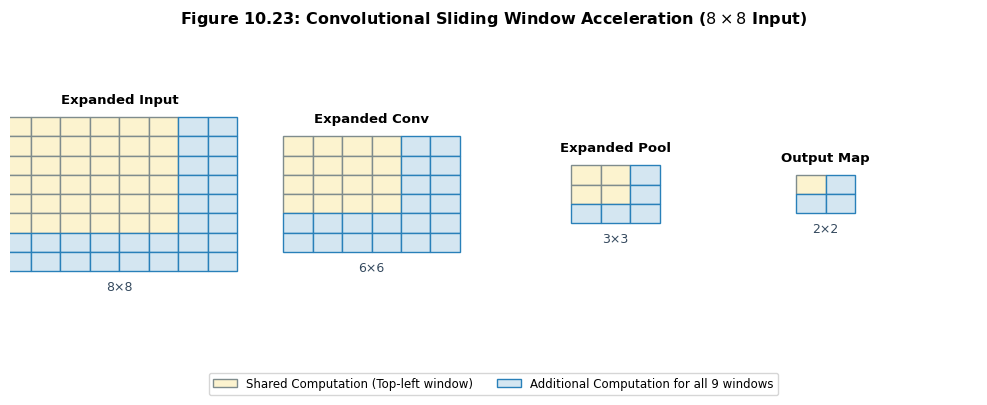

In [6]:
# Figure 10.23: 畳み込みスライディングウィンドウの加速
from common.object_detection import generate_figure_10_23
import matplotlib.pyplot as plt

fig10_23 = generate_figure_10_23()
plt.show()


## 5. 10.4.4 スケール横断検出 (Detection Across Scales)

実世界の物体は、カメラからの距離や姿勢によって多様なスケール（大きさ）およびアスペクト比（縦横比）で出現します。
検出器側の受容野サイズを何十通りも用意して学習させる代わりに、**「入力画像のほうを複数の倍率でリサイズ（スケーリング）し、単一の固定検出ウィンドウで走査する」**手法（画像ピラミッド）が極めて合理的です。

検出されたウィンドウ座標 $(x_{\text{scaled}}, y_{\text{scaled}}, w_{\text{scaled}}, h_{\text{scaled}})$ は、拡大縮小率 $s_x, s_y$ を用いて直ちに元の画像空間へと逆投影されます：
$$x_{\text{orig}} = \frac{x_{\text{scaled}}}{s_x}, \quad w_{\text{orig}} = \frac{w_{\text{scaled}}}{s_x}$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_24.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_24.png


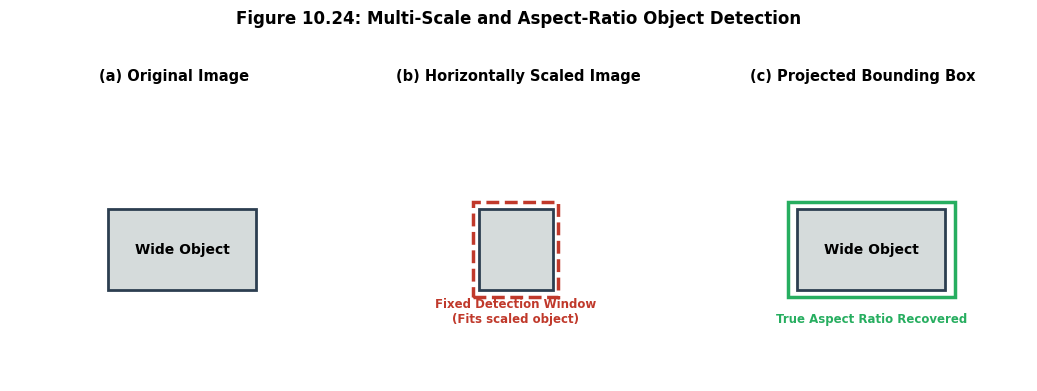

In [7]:
# Figure 10.24: スケール・アスペクト比横断検出
from common.object_detection import generate_figure_10_24
import matplotlib.pyplot as plt

fig10_24 = generate_figure_10_24()
plt.show()


## 6. 10.4.5 重複抑制 NMS (Non-Max Suppression)

稠密なスライディングウィンドウ走査や領域提案を行うと、同一の物体インスタンスに対してわずかに位置のずれた大量の候補矩形が重複して検出されます。
これを単一の最良なバウンディングボックスへと統合・間引く後処理アルゴリズムが **Non-Max Suppression (NMS)** です。

### NMS アルゴリズムの手順
1. **確信度閾値処理**: クラス予測確率が一定閾値（例: $0.7$）未満の低信頼ボックスを破棄する。
2. **スコア降順ソート**: 残ったボックスを検出確率の高い順に整列する。
3. **最良候補の選定**: 最も高い確率を持つボックス $B^*$ を「確定検出（Winner）」として保存する。
4. **IoU による重複排除**: $B^*$ との $\mathrm{IoU}(B^*, B_j)$ が閾値（例: $0.5$）を超える近接ボックス $B_j$ をすべて破棄する。
5. **反復**: 未処理のボックスがなくなるまでステップ 3 〜 4 を繰り返す。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_25.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_25.png


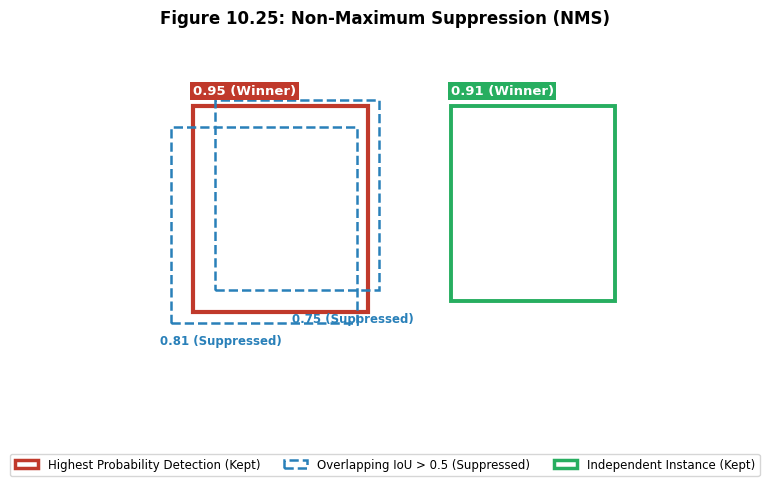

In [8]:
# Figure 10.25: Non-Maximum Suppression (NMS) の動作
from common.object_detection import generate_figure_10_25
import matplotlib.pyplot as plt

fig10_25 = generate_figure_10_25()
plt.show()


### Figure 10.25 の観察
- 左側の同一物体に対して得られた3つの候補（赤: 0.95, 青: 0.81, 0.75）のうち、最高スコアの赤色矩形が採用され、重複する青色矩形は IoU 閾値超過により完全に抑制されます。
- 右側に位置する独立した物体（緑: 0.91）は、左側の勝者矩形との IoU が 0 であるため、抑制されることなく独立した検出として正しく保持されます。


## 7. 10.4.6 高速領域提案ネットワーク (Fast Region CNNs)

画像全体を盲目的に稠密走査するスライディングウィンドウ法は、背景が大半を占める画像では無駄が多くなります。

### 領域ベース CNN の進化系譜
1. **R-CNN (Girshick et al., 2014)**:
   - 外部アルゴリズム（Selective Search）で物体らしき領域提案（Region Proposals: 約2000個）を抽出し、各パッチをリサイズして個別に巨大CNNに通す（極めて低速）。
2. **Fast R-CNN (Girshick, 2015)**:
   - 画像全体に対して**1回だけ畳み込み特徴マップを計算**。各領域提案に対応する特徴マップ上のパッチを **RoI Pooling (Region of Interest Pooling)** により固定サイズに変換し、全結合層で分類と座標オフセット回帰を同時に実行。
3. **Faster R-CNN (Ren et al., 2015)**:
   - 領域提案自体もCNN内部の **RPN (Region Proposal Network)** に統合し、エンド・ツー・エンドの完全微分可能パイプラインを確立。
4. **1段検出器 (Single-Stage Detectors: YOLO, SSD)**:
   - 領域提案を完全に排し、グリッドセル上に配置されたアンカーボックス（Anchor Boxes）に対する分類とオフセット回帰を直接同時に解くことで、リアルタイム推論速度（30〜60 FPS以上）を達成。


## 8. 数値検証セル

本節で扱った IoU の幾何計算、演習 10.12 の計算量削減比率、および NMS の選定ロジックを自動検証します。


In [9]:
# 数値検証と数理的整合性のアサーション
import numpy as np
from common.object_detection import (
    BoundingBox,
    NonMaxSuppression,
    analyze_sliding_window_efficiency,
)

# 1. IoU の幾何学的計算の検証
box1 = np.array([0.0, 0.0, 4.0, 4.0])
box2 = np.array([2.0, 0.0, 6.0, 4.0])
# Intersection: [2, 0, 4, 4] -> Area = 8
# Union: 16 + 16 - 8 = 24
# IoU = 8 / 24 = 1/3
assert np.isclose(BoundingBox.compute_iou(box1, box2), 1.0 / 3.0), "IoU calculation mismatch!"

# 2. 演習 10.12: スライディングウィンドウ計算効率の検証
stats = analyze_sliding_window_efficiency()
assert stats["single_pass_total"] == 148, "6x6 single pass MAC count"
assert stats["naive_total_multiplications"] == 1332, "9-window naive MAC count"
assert stats["conv_expanded_total_multiplications"] == 340, "8x8 expanded conv MAC count"
assert np.isclose(stats["speedup_ratio"], 1332.0 / 340.0), "Speedup ratio mismatch"
print(f"Exercise 10.12 Speedup Ratio: {stats['speedup_ratio']:.3f}x verified!")

# 3. NMS アルゴリズムの動作検証
test_boxes = np.array([
    [1.5, 2.0, 4.7, 5.8],
    [1.1, 1.8, 4.5, 5.4],
    [6.2, 2.2, 9.2, 5.8],
    [0.0, 0.0, 1.0, 1.0],
])
test_scores = np.array([0.95, 0.81, 0.91, 0.35])
kept_indices = NonMaxSuppression.apply(test_boxes, test_scores, score_threshold=0.7, iou_threshold=0.5)
assert kept_indices == [0, 2], f"NMS kept indices mismatch: {kept_indices}"

print("All mathematical & algorithmic assertions for Section 10.4 passed successfully!")


Exercise 10.12 Speedup Ratio: 3.918x verified!
All mathematical & algorithmic assertions for Section 10.4 passed successfully!


## 9. まとめと第10章第10.5節への展望

### 本節（10.4）の要点まとめ
1. **物体検出とバウンディングボックス**:
   - 連続座標ベクトル $(b_x, b_y, b_W, b_H)$ とマルチタスク損失による位置特定（Figure 10.19）。
   - $(C+1)$ ソフトマックスと2段階確率モデルの数学的等価性（演習 10.11）。
2. **IoU 評価指標**:
   - 積集合と和集合の面積比によるスケール不変な重なり度定量化（Figure 10.20）。
3. **畳み込みスライディングウィンドウの計算優位性**:
   - 素朴走査の計算重複（Figure 10.21）を、全結合層の畳み込み層への転換により解消（Figure 10.22, 10.23）。
   - 9回走査において約 $3.92$ 倍の計算量削減を達成（演習 10.12）。
4. **スケール横断検出と NMS**:
   - 入力画像のスケーリングと逆投影による多スケール検出（Figure 10.24）。
   - 確信度順位付けと IoU 閾値抑制による重複矩形の排除（Figure 10.25）。
5. **領域提案ネットワークの進化**:
   - R-CNN から Fast R-CNN（RoI Pooling）、Faster R-CNN（RPN）、YOLOへと至るエンド・ツー・エンド高速化の軌跡。

---

### 次節への展開
次は **第10章 10.5 画像セグメンテーション (Image Segmentation)** に進みます。
セマンティックセグメンテーション（Figure 10.26）、畳み込みセグメンテーション、アップサンプリング（Unpooling: Figure 10.28, 10.29）、転置畳み込み（Transposed Convolution: Figure 10.30, 演習 10.13）、全畳み込みネットワーク（FCN: Figure 10.27）、および U-net アーキテクチャ（Figure 10.31）の数理と実装を展開します。
